In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

print("All imports successful!")

All imports successful!


In [2]:
# Paths
BASE_DIR    = Path("D:/MaternaVision")
RAW_DIR     = BASE_DIR / "data" / "raw"
TRAIN_DIR   = RAW_DIR / "training_set"
TEST_DIR    = RAW_DIR / "test_set"
TRAIN_CSV   = RAW_DIR / "training_set_pixel_size_and_HC.csv"
TEST_CSV    = RAW_DIR / "test_set_pixel_size.csv"

# Verify paths
print("Training folder exists:", TRAIN_DIR.exists())
print("Test folder exists    :", TEST_DIR.exists())
print("Training CSV exists   :", TRAIN_CSV.exists())
print("Test CSV exists       :", TEST_CSV.exists())

Training folder exists: True
Test folder exists    : True
Training CSV exists   : True
Test CSV exists       : True


In [3]:
# Load training annotations
df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)

print("=" * 50)
print("TRAINING SET")
print("=" * 50)
print(f"Total samples      : {len(df_train)}")
print(f"Columns            : {list(df_train.columns)}")
print()
print(df_train.head(10))

print()
print("=" * 50)
print("TEST SET")
print("=" * 50)
print(f"Total samples      : {len(df_test)}")
print(f"Columns            : {list(df_test.columns)}")
print()
print(df_test.head(5))

TRAINING SET
Total samples      : 999
Columns            : ['filename', 'pixel size(mm)', 'head circumference (mm)']

     filename  pixel size(mm)  head circumference (mm)
0  000_HC.png        0.069136                    44.30
1  001_HC.png        0.089659                    56.81
2  002_HC.png        0.062033                    68.75
3  003_HC.png        0.091291                    69.00
4  004_HC.png        0.061240                    59.81
5  005_HC.png        0.115814                    69.80
6  006_HC.png        0.065606                    67.84
7  007_HC.png        0.109362                    62.80
8  008_HC.png        0.077655                    62.10
9  009_HC.png        0.121525                    62.31

TEST SET
Total samples      : 335
Columns            : ['filename', 'pixel size(mm)']

     filename  pixel size(mm)
0  000_HC.png        0.235857
1  001_HC.png        0.067973
2  002_HC.png        0.165202
3  003_HC.png        0.096674
4  004_HC.png        0.202203


In [4]:
print("=" * 50)
print("HC MEASUREMENT STATISTICS (mm)")
print("=" * 50)
print(f"Mean HC   : {df_train['head circumference (mm)'].mean():.2f} mm")
print(f"Std HC    : {df_train['head circumference (mm)'].std():.2f} mm")
print(f"Min HC    : {df_train['head circumference (mm)'].min():.2f} mm")
print(f"Max HC    : {df_train['head circumference (mm)'].max():.2f} mm")
print()
print("=" * 50)
print("PIXEL SIZE STATISTICS (mm/pixel)")
print("=" * 50)
print(f"Mean pixel size : {df_train['pixel size(mm)'].mean():.4f} mm/pixel")
print(f"Std pixel size  : {df_train['pixel size(mm)'].std():.4f} mm/pixel")
print(f"Min pixel size  : {df_train['pixel size(mm)'].min():.4f} mm/pixel")
print(f"Max pixel size  : {df_train['pixel size(mm)'].max():.4f} mm/pixel")

HC MEASUREMENT STATISTICS (mm)
Mean HC   : 174.38 mm
Std HC    : 65.28 mm
Min HC    : 44.30 mm
Max HC    : 346.40 mm

PIXEL SIZE STATISTICS (mm/pixel)
Mean pixel size : 0.1398 mm/pixel
Std pixel size  : 0.0530 mm/pixel
Min pixel size  : 0.0494 mm/pixel
Max pixel size  : 0.3933 mm/pixel


In [5]:
# Get all ultrasound images (not annotation masks)
train_images = sorted([
    f for f in TRAIN_DIR.glob("*.png")
    if "Annotation" not in f.name
])

test_images = sorted([
    f for f in TEST_DIR.glob("*.png")
])

print(f"Training ultrasound images : {len(train_images)}")
print(f"Test ultrasound images     : {len(test_images)}")

# Collect image sizes
heights, widths = [], []
for img_path in train_images[:100]:  # check first 100
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        h, w = img.shape
        heights.append(h)
        widths.append(w)

print()
print("=" * 50)
print("IMAGE SIZE STATISTICS")
print("=" * 50)
print(f"Width  — Mean: {np.mean(widths):.0f}  Min: {np.min(widths)}  Max: {np.max(widths)}")
print(f"Height — Mean: {np.mean(heights):.0f}  Min: {np.min(heights)}  Max: {np.max(heights)}")

Training ultrasound images : 999
Test ultrasound images     : 335

IMAGE SIZE STATISTICS
Width  — Mean: 800  Min: 800  Max: 800
Height — Mean: 540  Min: 540  Max: 540


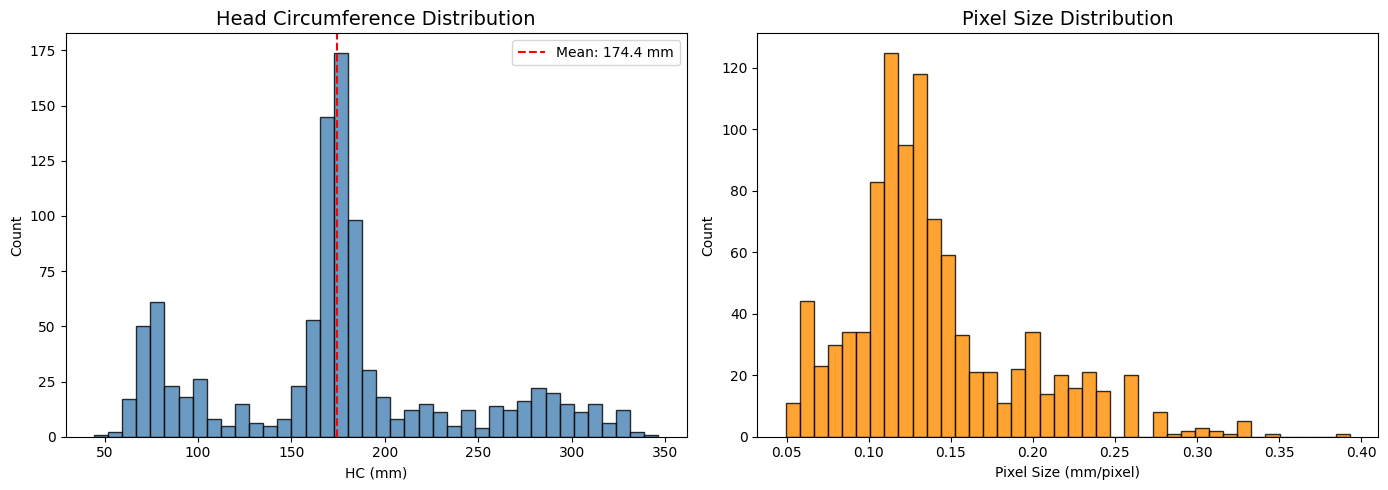

Plot saved!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# HC distribution
axes[0].hist(
    df_train['head circumference (mm)'],
    bins=40,
    color='steelblue',
    edgecolor='black',
    alpha=0.8
)
axes[0].set_title('Head Circumference Distribution', fontsize=14)
axes[0].set_xlabel('HC (mm)')
axes[0].set_ylabel('Count')
axes[0].axvline(
    df_train['head circumference (mm)'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean: {df_train['head circumference (mm)'].mean():.1f} mm"
)
axes[0].legend()

# Pixel size distribution
axes[1].hist(
    df_train['pixel size(mm)'],
    bins=40,
    color='darkorange',
    edgecolor='black',
    alpha=0.8
)
axes[1].set_title('Pixel Size Distribution', fontsize=14)
axes[1].set_xlabel('Pixel Size (mm/pixel)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('hc_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

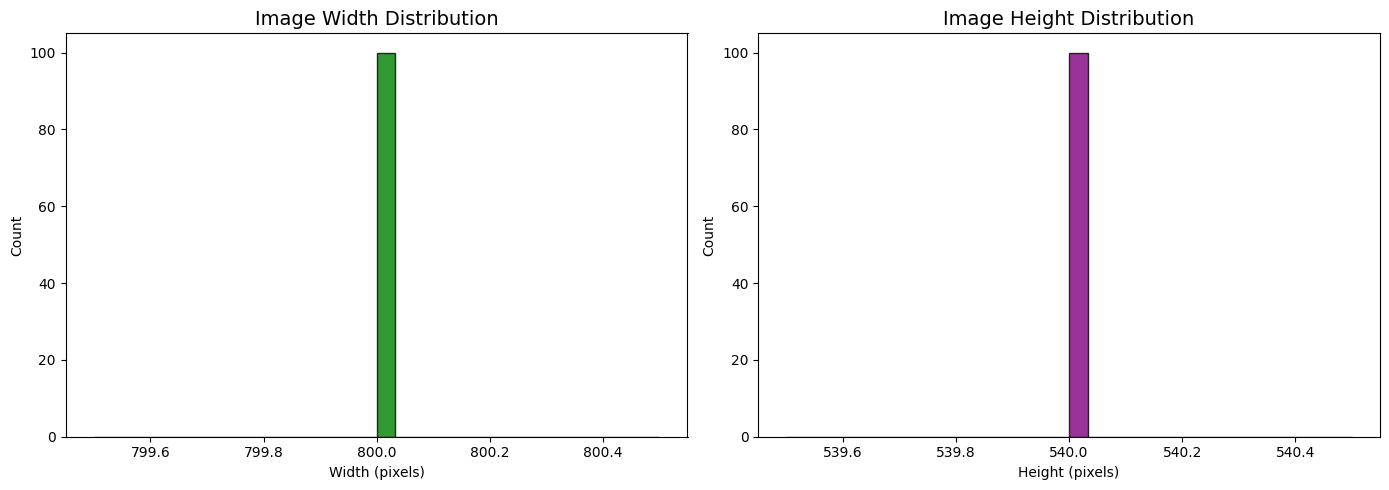

Plot saved!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(widths, bins=30, color='green', edgecolor='black', alpha=0.8)
axes[0].set_title('Image Width Distribution', fontsize=14)
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Count')

axes[1].hist(heights, bins=30, color='purple', edgecolor='black', alpha=0.8)
axes[1].set_title('Image Height Distribution', fontsize=14)
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('image_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

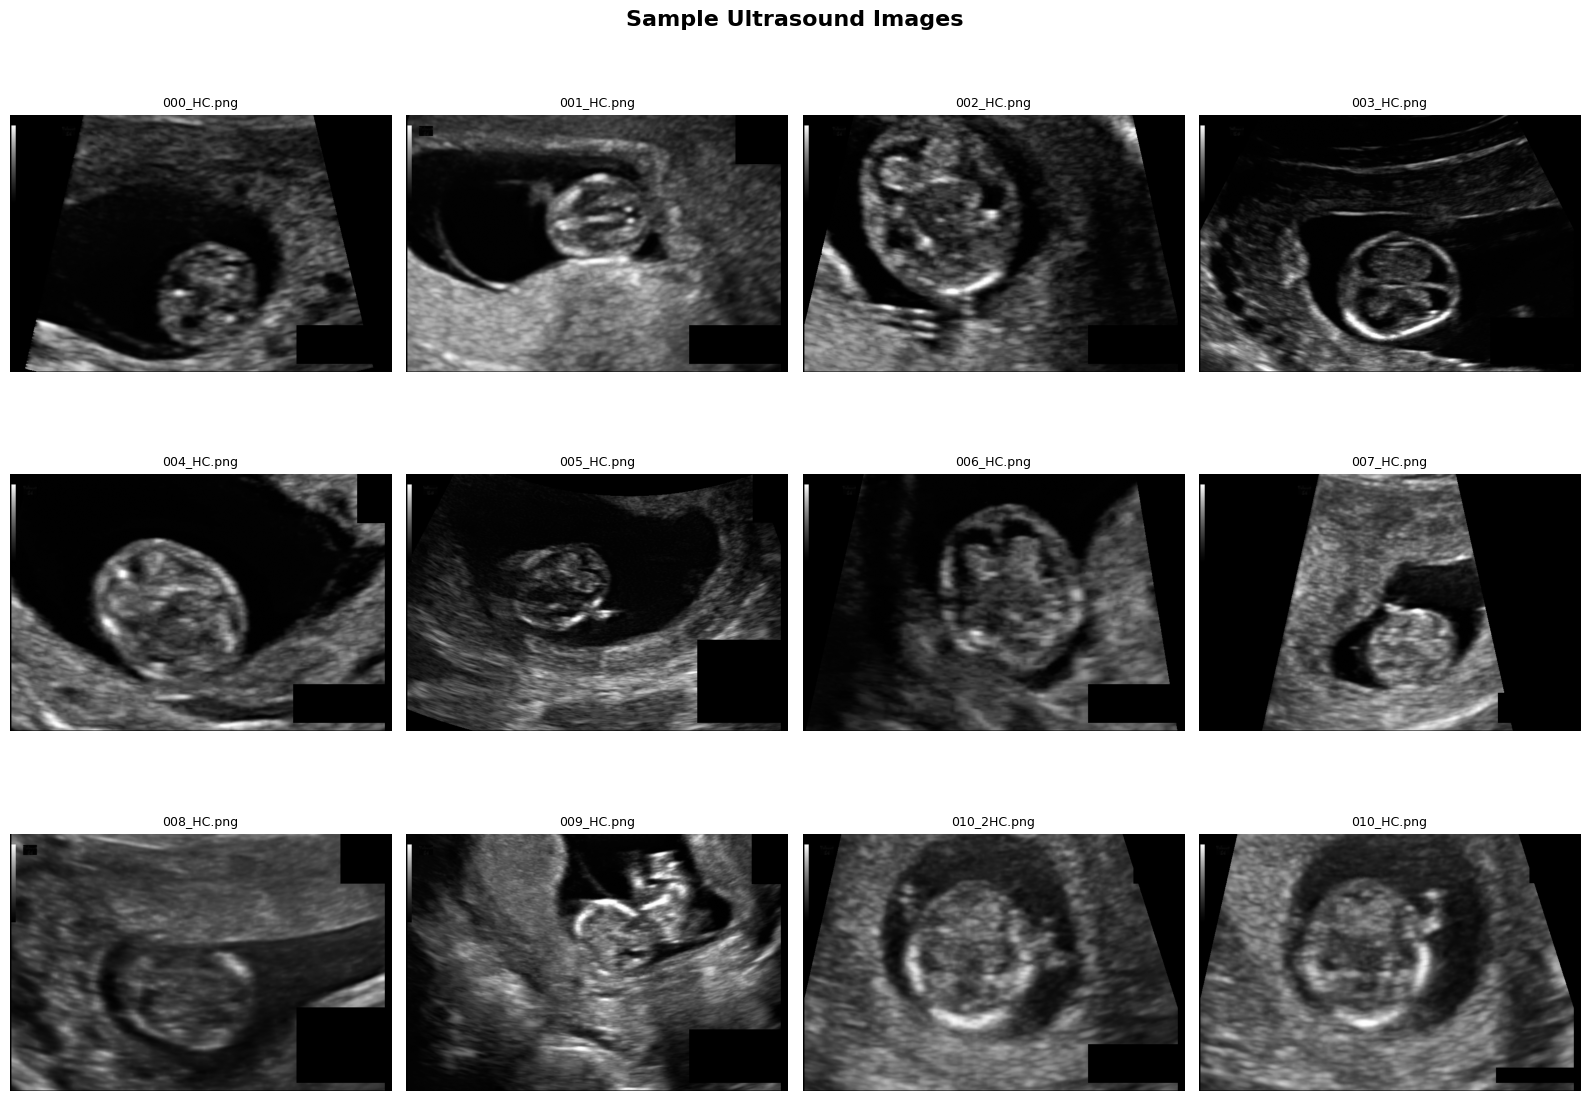

Plot saved!


In [8]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, img_path in enumerate(train_images[:12]):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(img_path.name[:15], fontsize=9)
    axes[i].axis('off')

plt.suptitle('Sample Ultrasound Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

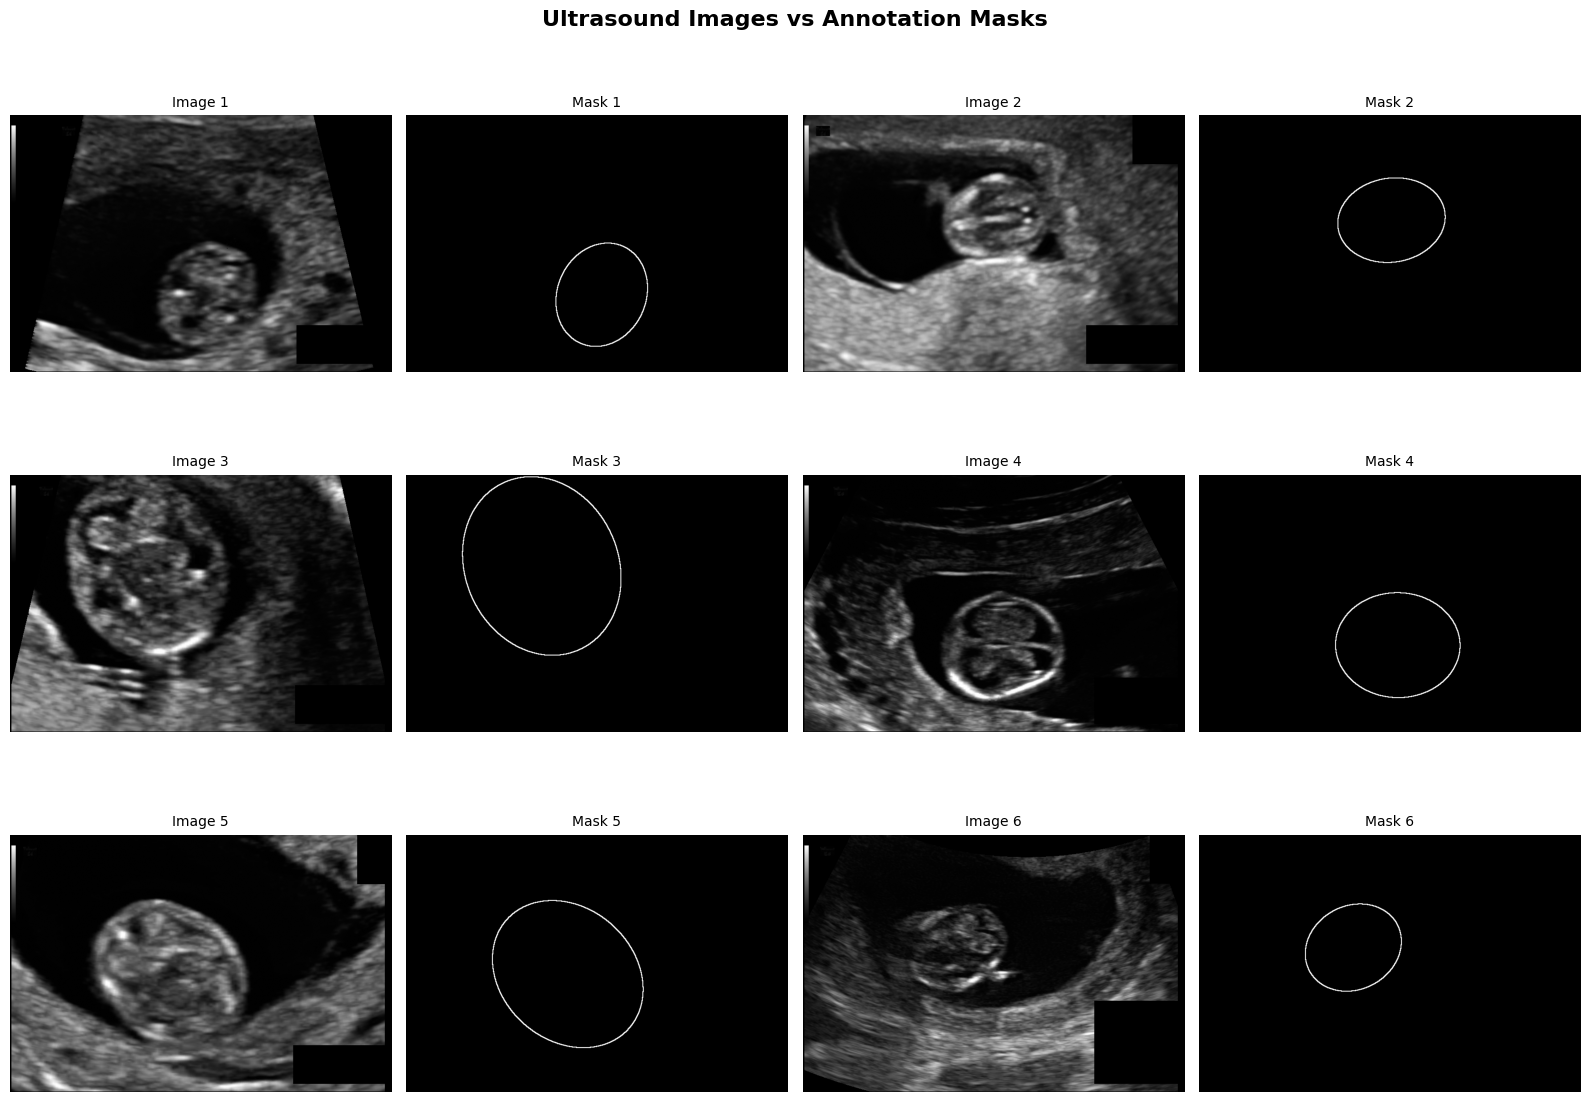

Plot saved!


In [9]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()  # <-- Add this line!

for i in range(6):
    img_path  = train_images[i]
    mask_name = img_path.name.replace("_HC.png", "_HC_Annotation.png")
    mask_path = TRAIN_DIR / mask_name

    img  = cv2.imread(str(img_path),  cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    # Show ultrasound
    axes[i*2].imshow(img, cmap='gray')
    axes[i*2].set_title(f'Image {i+1}', fontsize=10)
    axes[i*2].axis('off')

    # Show mask
    if mask is not None:
        axes[i*2+1].imshow(mask, cmap='gray')
        axes[i*2+1].set_title(f'Mask {i+1}', fontsize=10)
    axes[i*2+1].axis('off')

plt.suptitle('Ultrasound Images vs Annotation Masks', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('image_mask_pairs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [10]:
def extract_ellipse_from_mask(mask_path):
    """
    Extract ellipse parameters from annotation mask.
    Returns ellipse center, axes, angle.
    """
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None

    # Threshold
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    # Find contours
    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return None

    # Get largest contour
    largest = max(contours, key=cv2.contourArea)

    if len(largest) < 5:
        return None

    # Fit ellipse
    ellipse = cv2.fitEllipse(largest)
    center, axes, angle = ellipse

    return {
        'center_x'  : center[0],
        'center_y'  : center[1],
        'axis_a'    : axes[0] / 2,   # semi-minor (BPD/2)
        'axis_b'    : axes[1] / 2,   # semi-major (OFD/2)
        'angle'     : angle,
    }


# Test on first image
mask_path = TRAIN_DIR / train_images[0].name.replace(
    "_HC.png", "_HC_Annotation.png"
)
result = extract_ellipse_from_mask(mask_path)
print("Ellipse parameters for first image:")
print(f"  Center    : ({result['center_x']:.1f}, {result['center_y']:.1f})")
print(f"  Semi-minor (BPD/2) : {result['axis_a']:.1f} px")
print(f"  Semi-major (OFD/2) : {result['axis_b']:.1f} px")
print(f"  Angle     : {result['angle']:.1f}°")

Ellipse parameters for first image:
  Center    : (409.4, 377.8)
  Semi-minor (BPD/2) : 93.6 px
  Semi-major (OFD/2) : 111.7 px
  Angle     : 23.6°


In [11]:
def extract_landmarks(ellipse_params):
    """
    Extract 4 landmark points from ellipse:
    - 2 points for BPD (minor axis endpoints)
    - 2 points for OFD (major axis endpoints)
    """
    cx    = ellipse_params['center_x']
    cy    = ellipse_params['center_y']
    a     = ellipse_params['axis_a']   # semi-minor = BPD/2
    b     = ellipse_params['axis_b']   # semi-major = OFD/2
    angle = np.radians(ellipse_params['angle'])

    cos_a = np.cos(angle)
    sin_a = np.sin(angle)

    # BPD landmarks (minor axis endpoints)
    bpd_x1 = cx + a * (-sin_a)
    bpd_y1 = cy + a * cos_a
    bpd_x2 = cx - a * (-sin_a)
    bpd_y2 = cy - a * cos_a

    # OFD landmarks (major axis endpoints)
    ofd_x1 = cx + b * cos_a
    ofd_y1 = cy + b * sin_a
    ofd_x2 = cx - b * cos_a
    ofd_y2 = cy - b * sin_a

    return {
        'bpd_x1': bpd_x1, 'bpd_y1': bpd_y1,
        'bpd_x2': bpd_x2, 'bpd_y2': bpd_y2,
        'ofd_x1': ofd_x1, 'ofd_y1': ofd_y1,
        'ofd_x2': ofd_x2, 'ofd_y2': ofd_y2,
    }


# Test
landmarks = extract_landmarks(result)
print("Landmarks for first image:")
for k, v in landmarks.items():
    print(f"  {k}: {v:.1f}")

Landmarks for first image:
  bpd_x1: 371.9
  bpd_y1: 463.5
  bpd_x2: 447.0
  bpd_y2: 292.0
  ofd_x1: 511.8
  ofd_y1: 422.6
  ofd_x2: 307.1
  ofd_y2: 333.0



Image 1: 000_HC.png


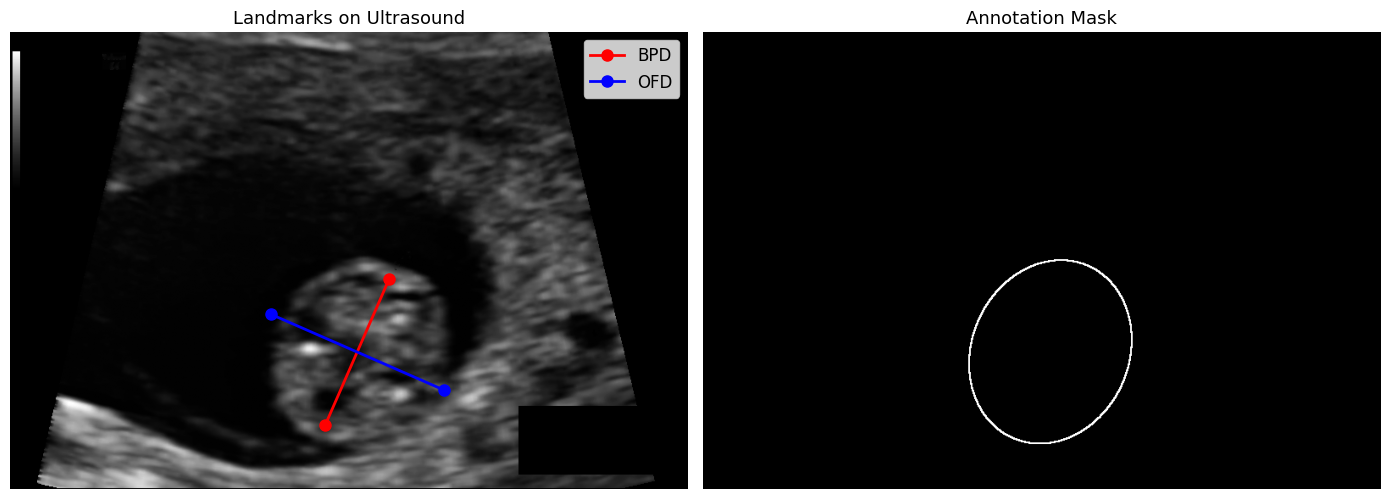


Image 2: 001_HC.png


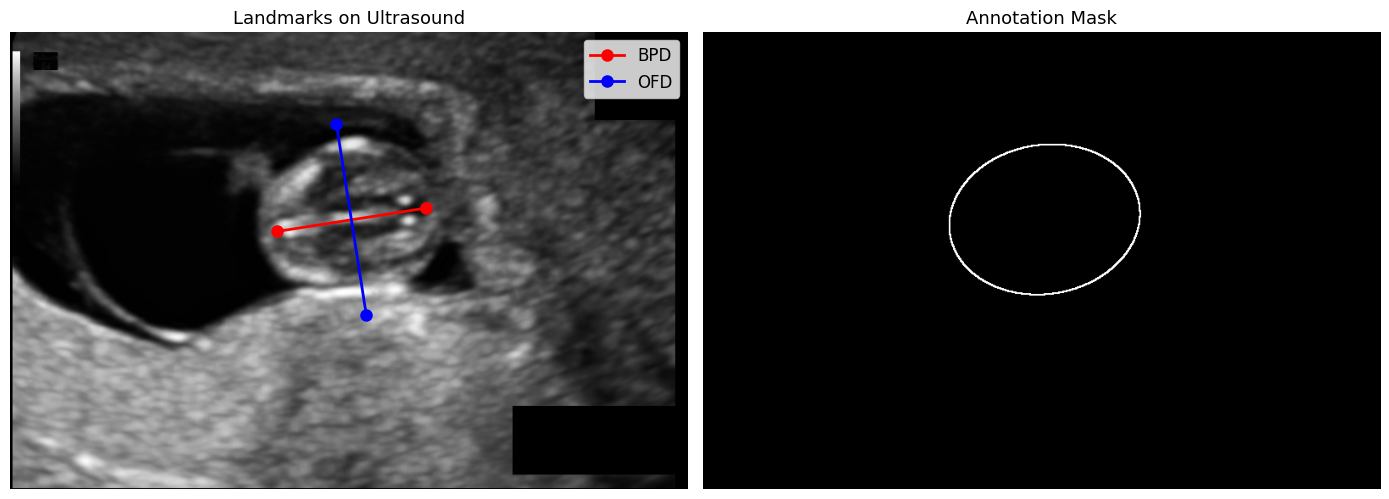


Image 3: 002_HC.png


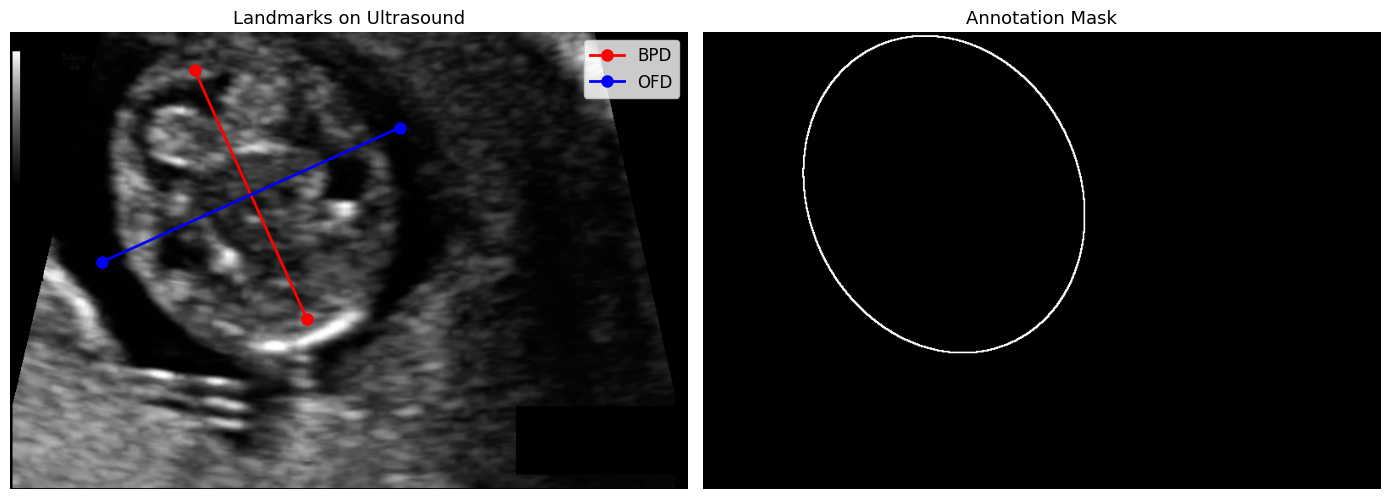

In [12]:
def visualise_landmarks(img_path, mask_path):
    img  = cv2.imread(str(img_path),  cv2.IMREAD_GRAYSCALE)
    ellipse_params = extract_ellipse_from_mask(mask_path)

    if ellipse_params is None:
        print("No ellipse found")
        return

    landmarks = extract_landmarks(ellipse_params)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Original image with landmarks
    axes[0].imshow(img, cmap='gray')
    axes[0].plot(
        [landmarks['bpd_x1'], landmarks['bpd_x2']],
        [landmarks['bpd_y1'], landmarks['bpd_y2']],
        'r-o', linewidth=2, markersize=8, label='BPD'
    )
    axes[0].plot(
        [landmarks['ofd_x1'], landmarks['ofd_x2']],
        [landmarks['ofd_y1'], landmarks['ofd_y2']],
        'b-o', linewidth=2, markersize=8, label='OFD'
    )
    axes[0].legend(fontsize=12)
    axes[0].set_title('Landmarks on Ultrasound', fontsize=13)
    axes[0].axis('off')

    # Mask
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Annotation Mask', fontsize=13)
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig('landmark_visualisation.png', dpi=150, bbox_inches='tight')
    plt.show()


# Test on first 3 images
for i in range(3):
    img_path  = train_images[i]
    mask_path = TRAIN_DIR / img_path.name.replace(
        "_HC.png", "_HC_Annotation.png"
    )
    print(f"\nImage {i+1}: {img_path.name}")
    visualise_landmarks(img_path, mask_path)